# **Overview**

**Goal**: translate a short Vietnamese audio clip into English text - directly, from one model, with no intermediate Vietnamese transcript.

This is **direct speech-to-text translation**: instead of chaining ASR and machine translation, you train one model to map Vietnamese audio straight to English - harder than either step alone, and a window into how multilingual speech models work.

## **Description**

### **The task**
Audio in, English out, with no Vietnamese transcript in between: `f : Audio waveform → English string`

This differs from the cascaded approach (ASR → Vietnamese transcript → MT), which is easy to train and debug but lets errors compound - a misheard tone or dropped diacritic in stage 1 leaves stage 2 nothing to recover from. A direct model trains end-to-end on (audio, English) pairs and commits to English phrasing without ever materializing a transcript. Whisper's built-in translate mode is a strong starting point.

### **The data**

2,481 clips, ~9.1 h total. Each 7-15 s, mono, 16 kHz, `.wav`. Sampled from public Vietnamese YouTube (current-affairs and culture commentary), with web-audio conditions: background music, reverb, varied accents, occasional English code-switching.

No training set is provided - all 2,481 clips are the test set. You train on public external corpora and predict on these. You get `sample_submission.csv` (every clip_id) and the `.wav` files at `/kaggle/input/competitions/assignment-2-speech-translation`; the English references are held out for scoring.

## **Evaluation**

### **Metric**

**Corpus-level BLEU-4** between your English and the hidden references

- Moses 13a tokenizer, lowercase, no smoothing. Range 0-100, higher is better. BLEU is the geometric mean of clipped n-gram precisions times a brevity penalty that punishes short output:

Scoring is bit-identical to:

`sacrebleu.corpus_bleu(hyps, [refs], lowercase=True, tokenize="13a")`

Run it on a held-out split (e.g. FLEURS Vi→En test) to check scores locally.

**Leaderboard**: the live board reflects 30% of the test set (public); final standings use the held-out 70% (private), revealed at close. Stratified by audio source.

### **Submission**
Submit a Kaggle notebook that loads the test audio, runs your model, and writes `submission.csv` to the working directory with two columns:

```csv
clip_id,prediction
spd_4kn7lnDyxbw_chunk0131_1744305_1758868,the future of our cities will depend on metro lines and well planned satellite towns
```

`clip_id` must match the `.wav` file stems exactly (no extension); use `sample_submission.csv` as your template.

`prediction` is one line of plain English; newlines become spaces.

Exactly one row per `clip_id`. Empty, null, duplicate, or missing rows are rejected.

In [ ]:
import torch

# Confirm a GPU is attached - training and inference both need one.
assert torch.cuda.is_available(), \
    "No GPU found. Settings → Accelerator → GPU T4 ×2 (or any GPU)."

# Quick sanity check that CUDA actually works (catches a broken runtime early).
_ = torch.randn(8, 8, device="cuda") @ torch.randn(8, 8, device="cuda")
print(f"torch={torch.__version__} | {torch.cuda.get_device_name(0)}")

torch=2.11.0+cu128 | NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
import importlib, subprocess, sys

# datasets<3.0 - the FLEURS loader script was removed in datasets 3.x, so we pin an older version.
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "datasets<3.0"])

# peft = the LoRA library. --no-deps so pip doesn't try to swap out Kaggle's PyTorch.
if importlib.util.find_spec("peft") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "peft"])

# evaluate + sacrebleu - used to measure BLEU.
for pkg in ("evaluate", "sacrebleu"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Re-check CUDA still works after installing (a bad install can break torch).
_ = torch.randn(8, 8, device="cuda") @ torch.randn(8, 8, device="cuda")
print("CUDA OK")

CUDA OK


In [ ]:
# Standard library + scientific Python
import gc, os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Union

import numpy as np
import pandas as pd
import soundfile as sf          # reads .wav audio files
import torch

# Hugging Face: datasets, LoRA (peft), and the Whisper model + Trainer
import evaluate
from datasets import Audio, DatasetDict, load_dataset, load_from_disk
from peft import LoraConfig, get_peft_model
from transformers import (
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    WhisperForConditionalGeneration,
    WhisperProcessor,
)

# Settings

**The knobs**. These are the settings you'll spend the competition experimenting with. They're at plain, modest defaults on purpose - changing them (and understanding why a change helps) is the whole point.

In [ ]:
# --- The knobs. Plain starting points, not tuned values - these are yours to change. ---
MODEL_ID         = "openai/whisper-medium"   # an allowed Whisper variant
NUM_EPOCHS       = 1                        # how many passes over the training data
TRAIN_BATCH      = 8                       # clips per training step (per GPU)
GRAD_ACCUM       = 4                         # effective batch = TRAIN_BATCH * GRAD_ACCUM
LEARNING_RATE    = 1e-5                       # how big each training step is
INFER_BATCH      = 8                         # clips translated at once at the end
INFER_BEAMS      = 2                         # beams used when decoding
SAMPLING_RATE    = 16_000                    # Whisper expects 16 kHz audio
NO_REPEAT_NGRAM_SIZE = 3

In [ ]:
# =========================
# Shared decoding config
# =========================

GENERATION_KWARGS = {
    "num_beams": INFER_BEAMS,
    "no_repeat_ngram_size": NO_REPEAT_NGRAM_SIZE,
    # "max_new_tokens": 225,
}

LANGUAGE = "vi"
TASK = "translate"

**Where things get saved**. Paths for the cached dataset, the fine-tuned model, and the `submission.csv` that Kaggle scores.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Where files get read from / written to.
WORK_DIR     = Path("/content/drive/MyDrive/Project/NLP/Assignment 2") if Path("/content/drive/MyDrive/Project/NLP/Assignment 2").exists() else Path.cwd()
FLEURS_CACHE = WORK_DIR / "fleurs_vi_en"        # cached copy of the training data
OUT_DIR      = WORK_DIR / "whisper-medium-ft"    # where the fine-tuned adapter is saved
SUBMISSION   = WORK_DIR / "submission.csv"      # the file Kaggle scores

device = "cuda"
print(f"working dir: {WORK_DIR}")

working dir: /content/drive/MyDrive/Project/NLP/Assignment 2


# 1. Locate the competition test set

The competition dataset is mounted under `/kaggle/input/`. The block below grabs every `test/*.wav` in your attached competition data automatically. Running locally? Make sure the test wavs live in some `<dir>/test/*.wav` structure.

In [ ]:
mkdir -p ~/.kaggle && echo KGAT_ec2e170c774e2bf9812e7078f843e93a > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('assignment-2-speech-translation')

100%|██████████| 900M/900M [00:22<00:00, 41.4MB/s]

Extracting files...


In [ ]:
def find_test_dir() -> Path:
    """Find the folder of competition test .wav files under /kaggle/input/.

    The dataset can be attached inside a versioned subfolder, so we look at every
    `*/test` directory and keep whichever one actually holds the most .wav files.
    """
    comp_root = Path("/root/.cache/kagglehub/competitions/assignment-2-speech-translation")

    candidates = []
    if comp_root.exists():
        candidates = sorted(comp_root.glob("*/test"))

    if not candidates:
        raise FileNotFoundError(
            "No test/ directory found under /kaggle/input/. "

            "Attach the competition dataset via the right-hand sidebar."
        )

    # Pick the candidate folder containing the most .wav files.
    return max(candidates, key=lambda p: len(list(p.glob("*.wav"))))


TEST_DIR  = find_test_dir()

TEST_WAVS = sorted(TEST_DIR.glob("*.wav"))   # every test clip, sorted by filename
print(f"Test dir : {TEST_DIR}")
print(f"Test wavs: {len(TEST_WAVS)}")



Test dir : /root/.cache/kagglehub/competitions/assignment-2-speech-translation/public_release_v2/test
Test wavs: 2481


# 2. Load FLEURS Vi/En as training data

FLEURS pairs Vietnamese audio with English sentence-aligned transcriptions. ~2.8k Vi training clips, ~5 s each - small but enough for a meaningful LoRA fine-tune.

**Want to swap in a different corpus?** Replace this cell with whatever public Vi-audio + En-text dataset you like (CoVoST 2, VIVOS + MT'd labels, CommonVoice + MT, etc.). The rest of the pipeline is dataset-agnostic as long as `dataset["train"]` and `dataset["validation"]` end up with audio and translation columns.

In [ ]:
# FLEURS ships Vietnamese and English separately; we pair them by their shared `id`
# to build (Vietnamese audio, English text) examples. The result is cached to disk so
# this one-time download + processing only happens on the first run.
if FLEURS_CACHE.is_dir():
    dataset = load_from_disk(str(FLEURS_CACHE))
    print(f"Loaded FLEURS from cache: {FLEURS_CACHE}")
else:
    print("Downloading FLEURS vi_vn + en_us (one-time, ~5 min)…")
    fleurs_vi = load_dataset("google/fleurs", "vi_vn", trust_remote_code=True)
    fleurs_en = load_dataset("google/fleurs", "en_us", trust_remote_code=True)

    splits = {}
    for split in ("train", "validation", "test"):
        # Map each example id -> its English sentence.
        id_to_en = {ex["id"]: ex["transcription"] for ex in fleurs_en[split]}

        # Keep only Vietnamese clips that have a matching English sentence,
        # then attach that sentence as a new `translation` column.
        vi = fleurs_vi[split].filter(lambda ex: ex["id"] in id_to_en)
        vi = vi.map(lambda ex: {"translation": id_to_en[ex["id"]]})

        # Drop every column except the audio and its English translation.
        keep = ("audio", "translation")
        vi = vi.remove_columns([c for c in vi.column_names if c not in keep])
        splits[split] = vi

    # Tell the dataset the audio is 16 kHz, then save the paired data to disk.
    dataset = DatasetDict(splits).cast_column("audio", Audio(sampling_rate=SAMPLING_RATE))
    dataset.save_to_disk(str(FLEURS_CACHE))

print({k: len(v) for k, v in dataset.items()})
print("Sample translation:", dataset["train"][0]["translation"])

Loaded FLEURS from cache: /content/drive/MyDrive/Project/NLP/Assignment 2/fleurs_vi_en
{'train': 2927, 'validation': 361, 'test': 857}
Sample translation: following the process hjr-3 will be reviewed again by the next elected legislature in either 2015 or 2016 to remain in process


# 3. Prepare the data: processor, collator, and metric

Three small pieces the Trainer needs: the **processor** (converts audio/text ↔ numbers), the **data collator** (packs examples into training batches), and the **BLEU metric** (scores the validation set so you can watch it learn).

In [ ]:
# The processor bundles two tools: a feature extractor (audio → log-mel spectrogram,
# the image-like input Whisper actually reads) and a tokenizer (text ↔ token ids).
# language="vi", task="translate" sets the job: Vietnamese audio in, English text out.
processor = WhisperProcessor.from_pretrained(
    MODEL_ID,
    language="vi",
    task="translate")

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

**The data collator.** A "collator" is the function that turns a handful of raw examples into one padded batch of tensors the model can train on. This one works in four steps: audio → features, text → token ids, mask the padding, drop the leading start token.

In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """Turns a list of {audio, translation} examples into one padded batch for training."""
    processor: Any

    def __call__(self, features):
        # 1) Audio → log-mel features (Whisper's actual input).
        arrays = [np.array(f["audio"]["array"], dtype=np.float32) for f in features]
        batch = self.processor.feature_extractor(
            arrays, sampling_rate=SAMPLING_RATE, return_tensors="pt",
            padding="max_length", truncation=True,
        )
        # The model runs in bf16; generate() isn't autocast-wrapped, so match the dtype here.
        batch["input_features"] = batch["input_features"].to(torch.bfloat16)

        # 2) English text → token ids (the labels the model learns to produce).
        label_features = [
            {"input_ids": self.processor.tokenizer(f["translation"], truncation=True, max_length=225).input_ids}
            for f in features
        ]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # 3) Set padded label positions to -100 so the loss ignores them.
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # 4) Drop the leading start-of-sentence token - the model re-adds it internally.
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

**Validation metric - BLEU**. During training the Trainer translates the validation clips and scores them with BLEU (higher = closer to the reference English), so you can see learning happen instead of guessing.

In [ ]:
# BLEU measures how close the model's English output is to the reference translation.
# The Trainer calls this each epoch on the validation split so you can watch it improve.
bleu_metric = evaluate.load("sacrebleu")

In [ ]:
def compute_metrics(pred):
    pred_ids, label_ids = pred.predictions, pred.label_ids
    # Undo the -100 masking so the labels can be decoded back into text.
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    bleu = bleu_metric.compute(predictions=pred_str, references=[[l] for l in label_str], lowercase = True)
    return {"bleu": bleu["score"]}

# 4. Build the model

We load the base Whisper model, then attach small **LoRA** adapters so only a tiny fraction of the parameters actually train. That's what lets fine-tuning fit on a free T4 GPU.

In [ ]:
# Load the base Whisper model in bf16 (half precision → fits a T4, trains faster).
base = WhisperForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa"
)

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.75k [00:00<?, ?B/s]

In [ ]:
# Tell generation: Vietnamese audio → translate to English.
base.generation_config.language = LANGUAGE
base.generation_config.task = TASK

# Clear stale generation defaults so the settings we pass at predict time are the only ones in effect.
base.generation_config.num_beams = GENERATION_KWARGS["num_beams"]
base.generation_config.no_repeat_ngram_size = GENERATION_KWARGS["no_repeat_ngram_size"] # decoding inconsistency
base.generation_config.suppress_tokens = [] # clear suppress tokens
base.generation_config.forced_decoder_ids = None
base.config.suppress_tokens = None
base.config.begin_suppress_tokens = None
base.config.forced_decoder_ids = None

**Attach LoRA adapters.** Instead of retraining all ~240M parameters, we freeze them and train a small set of add-on matrices. That's what makes fine-tuning feasible on a free GPU.

In [ ]:
# LoRA = freeze the big pretrained model and train only tiny "adapter" matrices added
# into each linear layer. Far fewer trainable parameters → fits in T4 memory, trains fast.
# r and lora_alpha control the adapter size; they're starting points, not tuned values.
lora_cfg = LoraConfig(
    r=8, # can be changed
    lora_alpha=16, # can be changed
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
    bias="none",
)

In [ ]:
import subprocess
import sys

# Upgrade torchao to a compatible version (0.16.0 or higher)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchao>=0.16.0"])
print("Upgraded torchao to a compatible version.")

Upgraded torchao to a compatible version.


In [ ]:
model = get_peft_model(base, lora_cfg)
model.enable_input_require_grads()
model.print_trainable_parameters()   # prints how few parameters actually train

trainable params: 8,650,752 || all params: 772,508,672 || trainable%: 1.1198


## 5. Train

First the training settings (grouped by purpose), then we build the Trainer and run the loop. `load_best_model_at_end=True` keeps the checkpoint with the highest validation BLEU, not just the final one.

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUT_DIR),

    logging_strategy="epoch",
    logging_first_step=True,
    logging_dir=str(OUT_DIR / "logs"),

    # --- how long / how big ---
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,

    # --- learning schedule ---
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,

    # --- memory / precision ---
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    fp16=False, bf16=True,
    optim="adamw_torch",

    # --- evaluation & checkpoints (score BLEU + save once per epoch, keep the best) ---
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    generation_num_beams= GENERATION_KWARGS["num_beams"],
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,

    # --- misc ---
    report_to=[],
    push_to_hub=False,
    dataloader_num_workers=2,
    remove_unused_columns=False,
    label_names=["labels"],
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**Build the trainer and run.** `Seq2SeqTrainer` wires together the model, data, collator, and metric; `train()` runs the loop and prints loss + validation BLEU as it goes.

In [ ]:
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    data_collator=DataCollatorSpeechSeq2SeqWithPadding(processor=processor),
    compute_metrics=compute_metrics,
    processing_class=processor.feature_extractor,
)

trainer.train()

# Save the trained LoRA adapter + processor so the prediction step can load them.
model.save_pretrained(str(OUT_DIR))
processor.save_pretrained(str(OUT_DIR))
print(f"LoRA adapter saved to {OUT_DIR}")

Epoch,Training Loss,Validation Loss,Bleu
1,14.513224,3.646452,14.432415


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transform

LoRA adapter saved to /content/drive/MyDrive/Project/NLP/Assignment 2/whisper-medium-ft


## Validation Inference Function

In [ ]:
import subprocess
import sys

# Upgrade torchao to a compatible version (0.16.0 or higher)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchao>=0.16.0"])
print("Upgraded torchao to a compatible version.")

Upgraded torchao to a compatible version.


In [ ]:
# load the model and LoRA adapter again

import subprocess
import sys
import importlib

from peft import PeftModel
from transformers import WhisperForConditionalGeneration, WhisperProcessor

BASE_MODEL = "openai/whisper-medium"

base = WhisperForConditionalGeneration.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa",
).to(device)

ADAPTER_DIR = OUT_DIR

processor = WhisperProcessor.from_pretrained(ADAPTER_DIR)

model = PeftModel.from_pretrained(base, ADAPTER_DIR).to(device)



Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

In [ ]:
import sacrebleu

def translate_dataset(model, ds, batch_size=8):
    """
    Translate a Hugging Face Dataset split using the same decoding settings as test inference.
    This function should be your trusted local validation scorer.
    """
    model.eval()
    forced_ids = processor.get_decoder_prompt_ids(language=LANGUAGE, task=TASK)
    model_dtype = next(model.parameters()).dtype

    predictions = []

    for start in range(0, len(ds), batch_size):
        batch = ds[start:start + batch_size]

        arrays = [
            np.array(audio["array"], dtype=np.float32)
            for audio in batch["audio"]
        ]

        inputs = processor.feature_extractor(
            arrays,
            sampling_rate=SAMPLING_RATE,
            return_tensors="pt",
            padding=True,
        )

        feats = inputs.input_features.to(device, dtype=model_dtype)
        attn = inputs.attention_mask.to(device) if "attention_mask" in inputs else None

        with torch.no_grad():
            ids = model.generate(
                feats,
                attention_mask=attn,
                forced_decoder_ids=forced_ids,
                **GENERATION_KWARGS,
            )

        decoded = processor.tokenizer.batch_decode(ids, skip_special_tokens=True)
        predictions.extend(decoded)

    return predictions


def score_validation_like_test(model, validation_ds):
    """
    Run validation with the same generation function used for test.
    """
    predictions = translate_dataset(model, validation_ds, batch_size=8)
    references = validation_ds["translation"]

    bleu = sacrebleu.corpus_bleu(predictions, [references], lowercase = True)

    print(f"Matched validation BLEU: {bleu.score:.4f}")
    print(f"Decoding settings: {GENERATION_KWARGS}")

    return predictions, references, bleu.score

In [ ]:
val_predictions, val_references, val_bleu = score_validation_like_test(
    model,
    dataset["validation"]
)

Matched validation BLEU: 16.1406
Decoding settings: {'num_beams': 2, 'no_repeat_ngram_size': 3}


## Error Analysis

In [ ]:
from sacrebleu.metrics import BLEU

sentence_bleu = BLEU(effective_order=True)

def show_validation_errors(predictions, references, validation_dataset, n=20):
    """
    Print the worst validation examples by sentence-level BLEU.
    Sentence BLEU is noisy, but useful for finding obvious failure cases.
    """
    rows = []

    for i, (pred, ref) in enumerate(zip(predictions, references)):
        lowercased_pred = pred.lower() # Explicitly lowercase the prediction
        score = sentence_bleu.sentence_score(lowercased_pred, [ref]).score

        ex = validation_dataset[i]

        # Try to recover some useful identifier. This logic is inspired by the provided context.
        recording_id = None
        for key in ["id", "recording_id", "clip_id", "path", "file", "filename"]:
            if key in ex:
                recording_id = ex[key]
                break
        if recording_id is None and "audio" in ex:
            audio_obj = ex["audio"]
            if isinstance(audio_obj, dict) and "path" in audio_obj:
                recording_id = audio_obj["path"]
        if recording_id is None:
            recording_id = f"validation_index_{i}"

        rows.append({
            "idx": i,
            "recording_id": recording_id,
            "sentence_bleu": score,
            "prediction": lowercased_pred,
            "reference": ref,
        })

    df = pd.DataFrame(rows).sort_values("sentence_bleu", ascending=True)

    for _, row in df.head(n).iterrows():
        print("=" * 100)
        print(f"Index: {row['idx']}")
        print(f"Recording ID: {row['recording_id']}")
        print(f"Sentence BLEU: {row['sentence_bleu']:.2f}")
        print()
        print("PREDICTION:")
        print(row["prediction"])
        print()
        print("REFERENCE:")
        print(row["reference"])

    return df

In [ ]:
val_error_df = show_validation_errors(
    val_predictions,
    val_references,
    dataset["validation"],
    n=30
)

Index: 311
Recording ID: 7829487342299494550.wav
Sentence BLEU: 1.79

PREDICTION:
 ancient egyptian people during the reign of the king were shocked by the remains of ancient buildings that still exist until the next millennium.

REFERENCE:
new kingdom ancient egyptians marvelled at their predecessors monuments which were then well over a thousand year old
Index: 127
Recording ID: 155163866501153764.wav
Sentence BLEU: 2.15

PREDICTION:
 scientists believe that the south american wild cat, following the search for food, prey, and smell, has come to a place where prey has stood.

REFERENCE:
scientists think that ocelots follow and find animals to eat prey by smell sniffing for where they've been on the ground
Index: 26
Recording ID: 1104103894665075119.wav
Sentence BLEU: 2.36

PREDICTION:
 former governor of the state of newt greenwood governor of pantheon richard lorrie and female mayor mitchell batman turn of the fourth year and six

REFERENCE:
former house speaker newt gingrich texas 

## Decoding Experiments

In [ ]:
DECODING_EXPERIMENTS = [
    {
        "name": "beam_2_no_repeat_3",
        "kwargs": {
            "num_beams": 2,
            "no_repeat_ngram_size": 3,
        },
    },
    {
        "name": "beam_3_no_repeat_3",
        "kwargs": {
            "num_beams": 3,
            "no_repeat_ngram_size": 3,
        },
    },
    {
        "name": "beam_3_no_repeat_3",
        "kwargs": {
            "num_beams": 3,
            "no_repeat_ngram_size": 2,
        },
    },
]

experiment_results = []

for exp in DECODING_EXPERIMENTS:
    GENERATION_KWARGS = exp["kwargs"]

    preds, refs, bleu_score = score_validation_like_test(
        model,
        dataset["validation"]
    )

    experiment_results.append({
        "bleu": bleu_score,
        **exp["kwargs"],
    })

pd.DataFrame(experiment_results)

# 6. Predict on the competition test set

Merge the LoRA adapters back into the base weights and translate every test clip. (How the model decodes is set in the cell below - worth a close read.)

In [ ]:
ZERO_SHOT_MODEL_ID = "openai/whisper-large"

processor = WhisperProcessor.from_pretrained(
    ZERO_SHOT_MODEL_ID,
    language="vi",
    task="translate",
)

ft_model = WhisperForConditionalGeneration.from_pretrained(
    ZERO_SHOT_MODEL_ID,
    torch_dtype=torch.bfloat16,
).to(device)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.17G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.85k [00:00<?, ?B/s]

In [ ]:
# =========================
# Shared decoding config
# =========================

GENERATION_KWARGS = {
    "num_beams": 2,
    "no_repeat_ngram_size": 3,
    # "max_new_tokens": 225,
}

LANGUAGE = "vi"
TASK = "translate"

In [ ]:
def load_audio(path: Path) -> np.ndarray:
    """Read one .wav file as a mono, 16 kHz float array (what Whisper expects)."""
    array, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if array.ndim > 1:
        array = array.mean(axis=1)          # stereo → mono
    if sr != SAMPLING_RATE:
        import librosa
        array = librosa.resample(array, orig_sr=sr, target_sr=SAMPLING_RATE)
    return array.astype(np.float32)

**Translate a batch of clips**. A helper that loads each `.wav`, runs the model, and decodes the output ids back into English text - `INFER_BATCH` clips at a time.

In [ ]:
def translate_wavs(model, wavs: List[Path]) -> List[str]:
    """Translate a list of .wav files into English strings, INFER_BATCH clips at a time."""
    model.eval()
    forced_ids = processor.get_decoder_prompt_ids(language="vi", task="translate")
    model_dtype = next(model.parameters()).dtype
    outputs: List[str] = []
    for start in range(0, len(wavs), INFER_BATCH):
        batch = wavs[start:start + INFER_BATCH]
        arrays = [load_audio(p) for p in batch]
        inputs = processor.feature_extractor(
            arrays, sampling_rate=SAMPLING_RATE, return_tensors="pt", padding=True
        )
        feats = inputs.input_features.to(device, dtype=model_dtype)
        attn  = inputs.attention_mask.to(device) if "attention_mask" in inputs else None
        with torch.no_grad():
            ids = model.generate(
                feats,
                attention_mask=attn,
                forced_decoder_ids=forced_ids,
                **GENERATION_KWARGS,  # block repeated bigrams
                # max_new_tokens=225,
            )
        outputs.extend(processor.tokenizer.batch_decode(ids, skip_special_tokens=True))
        if (start // INFER_BATCH) % 20 == 0:
            print(f"  …{start + len(batch)}/{len(wavs)}")
    return outputs

**Run it on all the test clips**. This is the slow step - progress prints every ~160 clips.

In [ ]:
# Fold the LoRA adapter into the base weights, then translate every competition clip.
#ft_model = model.merge_and_unload().to(device)
print(f"Translating {len(TEST_WAVS)} test clips with beam={INFER_BEAMS}…")
predictions = translate_wavs(ft_model, TEST_WAVS)
print("Done.")

Translating 2481 test clips with beam=2…
  …8/2481
  …168/2481
  …328/2481
  …488/2481
  …648/2481
  …808/2481
  …968/2481
  …1128/2481
  …1288/2481
  …1448/2481
  …1608/2481
  …1768/2481
  …1928/2481
  …2088/2481
  …2248/2481
  …2408/2481
Done.


In [ ]:
forced_ids = processor.get_decoder_prompt_ids(
    language="vi",
    task="translate"
)

print(forced_ids)

[(1, 50278), (2, 50358), (3, 50363)]


7. Write `submission.csv`
Two columns - `clip_id`, `prediction` - one row per test clip. This is the file Kaggle will score.

In [ ]:
# Build the submission: one row per clip, columns clip_id + prediction.
# Any empty prediction is replaced with "_" so every clip has a non-empty entry.
submission = pd.DataFrame({
    "clip_id":    [p.stem for p in TEST_WAVS],
    "prediction": [p.strip() if p.strip() else "_" for p in predictions],
}).sort_values("clip_id").reset_index(drop=True)

submission.to_csv(SUBMISSION, index=False)
print(f"Wrote {len(submission)} predictions to {SUBMISSION}")
print(submission.head())

Wrote 2481 predictions to /content/drive/MyDrive/Project/NLP/Assignment 2/submission.csv
                                    clip_id  \
0  dbcb_A2-Rj67Cf8U_chunk0026_282306_295230   
1  dbcb_Fp0A8LZTC9o_chunk0027_296866_309662   
2  dbcb_Fp0A8LZTC9o_chunk0031_344002_356414   
3  dbcb_Fp0A8LZTC9o_chunk0032_357218_371742   
4  dbcb_Fp0A8LZTC9o_chunk0033_372578_384862   

                                          prediction  
0  The future of traffic in Vietnam is not in the...  
1  It could be the confusion sometimes caused by ...  
2  Here, life is still going on, people are still...  
3  According to all the dry numbers from internat...  
4  Living is not just about staying in a house or...  


# **Audio Distribution Comparison**

## Duration distribution

Validation duration stats:
count    361.000000
mean      11.910083
std        4.614657
min        4.320000
25%        8.820000
50%       11.160000
75%       13.800000
90%       17.700000
95%       21.000000
99%       28.704000
max       31.980000
Name: duration_sec, dtype: float64

Test duration stats:
count    2481.000000
mean       13.268514
std         0.866495
min         7.004000
25%        12.508000
50%        13.138500
75%        13.980000
90%        14.556000
95%        14.780000
99%        14.940000
max        14.990000
Name: duration_sec, dtype: float64

Sample rates:
split       sample_rate
test        16000          2481
validation  16000           361
Name: count, dtype: int64


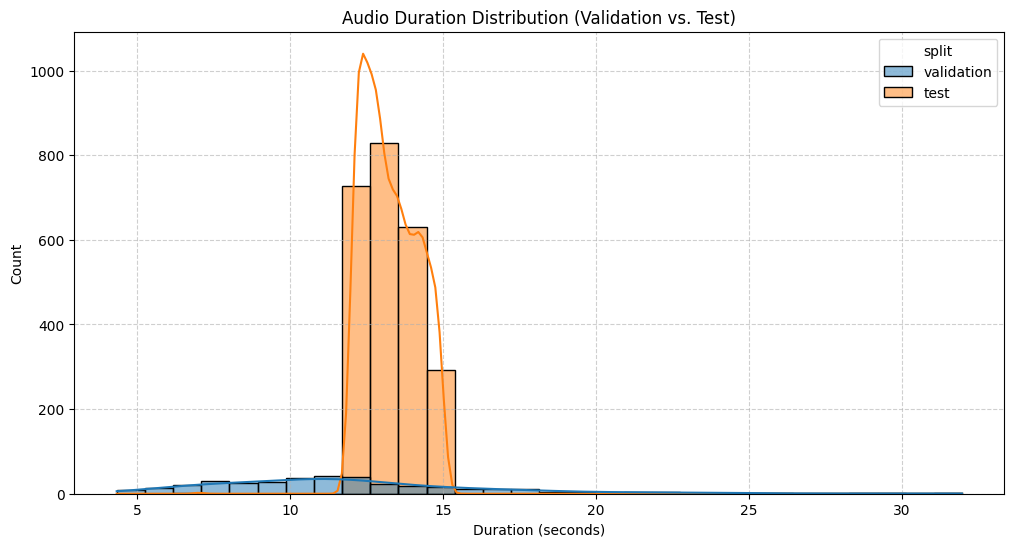

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import seaborn as sns

def get_validation_audio_stats(validation_ds):
    """
    Compute duration statistics for FLEURS validation audio.
    Validation audio is stored inside the Hugging Face dataset as arrays.
    """
    rows = []

    for i, ex in enumerate(validation_ds):
        audio = ex["audio"]
        y = np.asarray(audio["array"], dtype=np.float32)
        sr = audio["sampling_rate"]

        rows.append({
            "split": "validation",
            "idx": i,
            "duration_sec": len(y) / sr,
            "sample_rate": sr,
        })

    return pd.DataFrame(rows)


def get_test_audio_stats(test_wavs):
    """
    Compute duration statistics for competition test wavs.
    Uses soundfile.info() so it does not need to load full audio into memory.
    """
    rows = []

    for wav in test_wavs:
        info = sf.info(str(wav))

        rows.append({
            "split": "test",
            "clip_id": wav.stem,
            "path": str(wav),
            "duration_sec": info.frames / info.samplerate,
            "sample_rate": info.samplerate,
        })

    return pd.DataFrame(rows)


val_audio_stats = get_validation_audio_stats(dataset["validation"])
test_audio_stats = get_test_audio_stats(TEST_WAVS)

audio_stats = pd.concat(
    [val_audio_stats, test_audio_stats],
    ignore_index=True
)

print("Validation duration stats:")
print(val_audio_stats["duration_sec"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nTest duration stats:")
print(test_audio_stats["duration_sec"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nSample rates:")
print(audio_stats.groupby("split")["sample_rate"].value_counts())

# Plotting the duration distributions
plt.figure(figsize=(12, 6))
sns.histplot(data=audio_stats, x="duration_sec", hue="split", kde=True, bins=30)
plt.title("Audio Duration Distribution (Validation vs. Test)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## RMS loudness

In [ ]:
import librosa
import numpy as np

def rms_db(y):
    rms = np.sqrt(np.mean(y**2))
    return 20 * np.log10(rms + 1e-10)

def get_rms_stats_from_hf_dataset(hf_dataset):
    """Compute RMS stats for audio arrays directly from a Hugging Face dataset."""
    values = []
    for item in hf_dataset:
        audio_array = item['audio']['array']
        values.append(
            rms_db(audio_array)
        )
    return pd.Series(values)

def get_rms_stats_from_wav_paths(wav_paths):
    """Compute RMS stats for audio from WAV file paths."""
    values = []
    for path in wav_paths:
        y, sr = librosa.load(path, sr=None)
        values.append(
            rms_db(y)
        )
    return pd.Series(values)

val_rms = get_rms_stats_from_hf_dataset(dataset["validation"])
test_rms = get_rms_stats_from_wav_paths(TEST_WAVS)

print("Validation Loudness:", val_rms.mean())
print("Test Loudness:", test_rms.mean())

Validation Loudness: -38.78371811910913
Test Loudness: -19.206991


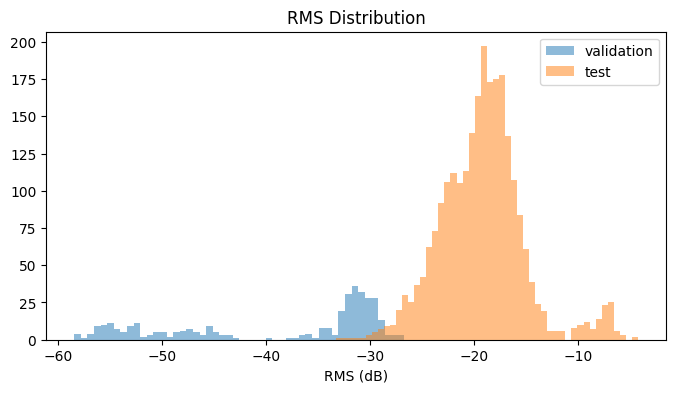

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(
    val_rms,
    bins=50,
    alpha=0.5,
    label="validation"
)

plt.hist(
    test_rms,
    bins=50,
    alpha=0.5,
    label="test"
)

plt.legend()
plt.xlabel("RMS (dB)")
plt.title("RMS Distribution")
plt.show()

## Leading/trailing silence ratio

Validation energy-based silence stats:
       speech_ratio  silence_ratio  leading_silence_ratio  \
count    361.000000     361.000000             361.000000   
mean       0.908969       0.091031               0.023757   
std        0.120348       0.120348               0.043634   
min        0.468687       0.000000               0.000000   
25%        0.823392       0.000000               0.000000   
50%        0.982222       0.017778               0.006312   
75%        1.000000       0.176608               0.019244   
90%        1.000000       0.294959               0.081778   
95%        1.000000       0.326599               0.120102   
99%        1.000000       0.393744               0.196208   
max        1.000000       0.531313               0.260055   

       trailing_silence_ratio  num_speech_intervals  
count              361.000000            361.000000  
mean                 0.021192              3.855956  
std                  0.040588              4.561466  
min         

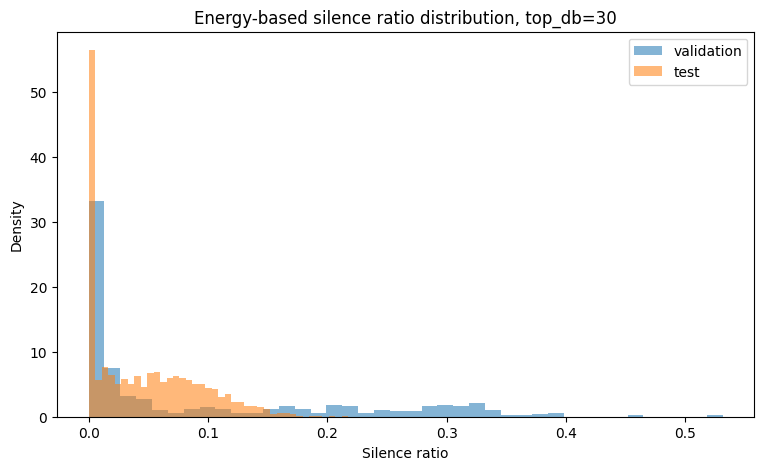

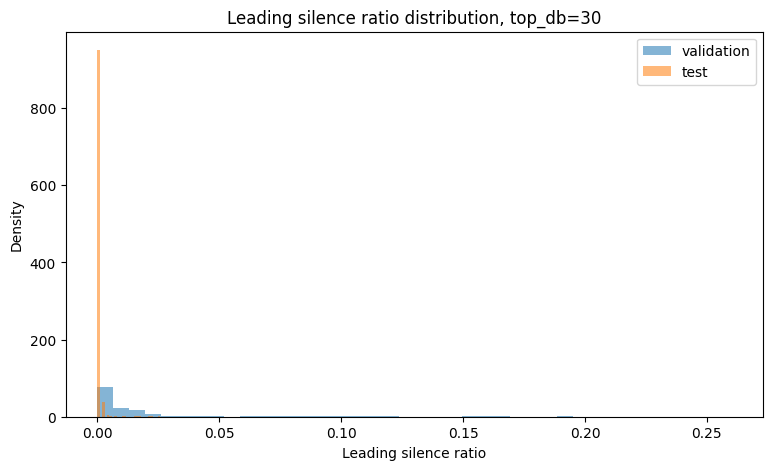

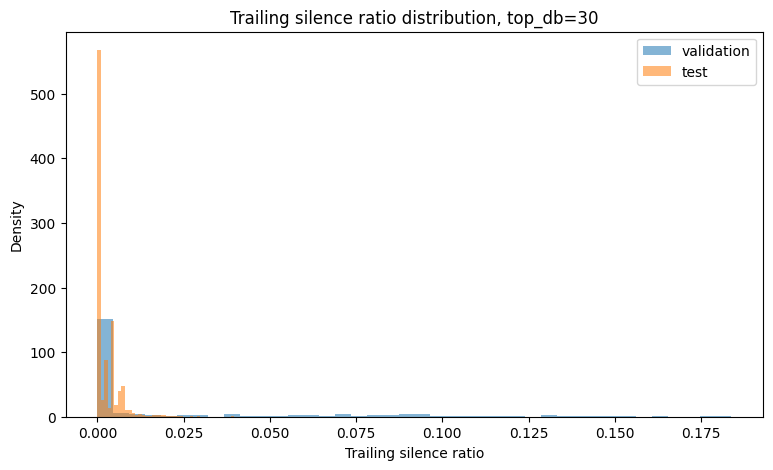

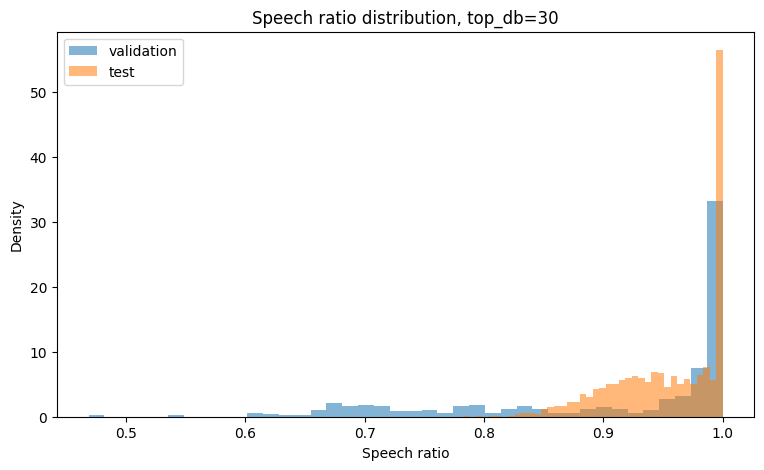

top_db = 20
Validation mean silence: 0.307569166864657
Test mean silence: 0.12727926489376842
Validation mean leading silence: 0.08757725674806967
Test mean leading silence: 0.0017236697672399297
Validation mean trailing silence: 0.08515007707584668
Test mean trailing silence: 0.00710624530430204
top_db = 30
Validation mean silence: 0.09103100121202355
Test mean silence: 0.0464403956103908
Validation mean leading silence: 0.02375718603316771
Test mean leading silence: 0.00036082718620152044
Validation mean trailing silence: 0.02119192176861151
Test mean trailing silence: 0.0024251945577070523
top_db = 40
Validation mean silence: 0.005191883002027341
Test mean silence: 0.014462082429626216
Validation mean leading silence: 0.004074432766484292
Test mean leading silence: 0.00010403053460581206
Validation mean trailing silence: 0.0005376552809388841
Test mean trailing silence: 0.0006117303602791456


In [ ]:
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt


def compute_energy_silence_from_array(y, sr, top_db=30):
    """
    Estimate speech/silence using librosa.effects.split.

    top_db controls how strict the speech detector is:
    - smaller top_db, e.g. 20: stricter, only louder regions count as speech
    - larger top_db, e.g. 40: more permissive, quieter regions also count as speech

    This is better than abs(y) < threshold because it adapts to the clip's own energy scale.
    """
    y = np.asarray(y, dtype=np.float32)

    if len(y) == 0:
        return {
            "duration_sec": 0.0,
            "speech_ratio": 0.0,
            "silence_ratio": 1.0,
            "leading_silence_ratio": 1.0,
            "trailing_silence_ratio": 1.0,
            "num_speech_intervals": 0,
        }

    intervals = librosa.effects.split(
        y,
        top_db=top_db,
    )

    duration_sec = len(y) / sr

    if len(intervals) == 0:
        return {
            "duration_sec": duration_sec,
            "speech_ratio": 0.0,
            "silence_ratio": 1.0,
            "leading_silence_ratio": 1.0,
            "trailing_silence_ratio": 1.0,
            "num_speech_intervals": 0,
        }

    speech_samples = sum(end - start for start, end in intervals)

    speech_ratio = speech_samples / len(y)
    silence_ratio = 1.0 - speech_ratio

    first_speech_start = intervals[0][0]
    last_speech_end = intervals[-1][1]

    leading_silence_ratio = first_speech_start / len(y)
    trailing_silence_ratio = (len(y) - last_speech_end) / len(y)

    return {
        "duration_sec": duration_sec,
        "speech_ratio": speech_ratio,
        "silence_ratio": silence_ratio,
        "leading_silence_ratio": leading_silence_ratio,
        "trailing_silence_ratio": trailing_silence_ratio,
        "num_speech_intervals": len(intervals),
    }


def compute_validation_energy_silence_stats(validation_ds, top_db=30):
    """
    Compute energy-based silence statistics for validation audio stored
    inside the Hugging Face dataset.
    """
    rows = []

    for i, ex in enumerate(validation_ds):
        audio = ex["audio"]

        y = np.asarray(audio["array"], dtype=np.float32)
        sr = audio["sampling_rate"]

        stats = compute_energy_silence_from_array(
            y=y,
            sr=sr,
            top_db=top_db,
        )

        rows.append({
            "split": "validation",
            "idx": i,
            "sample_rate": sr,
            **stats,
        })

    return pd.DataFrame(rows)


def compute_test_energy_silence_stats(test_wavs, top_db=30):
    """
    Compute energy-based silence statistics for test wav files.
    This loads audio because silence estimation needs the waveform.
    """
    rows = []

    for wav in test_wavs:
        y, sr = librosa.load(
            str(wav),
            sr=None,
            mono=True,
        )

        stats = compute_energy_silence_from_array(
            y=y,
            sr=sr,
            top_db=top_db,
        )

        rows.append({
            "split": "test",
            "clip_id": wav.stem,
            "path": str(wav),
            "sample_rate": sr,
            **stats,
        })

    return pd.DataFrame(rows)


TOP_DB = 30

val_energy_stats = compute_validation_energy_silence_stats(
    dataset["validation"],
    top_db=TOP_DB,
)

test_energy_stats = compute_test_energy_silence_stats(
    TEST_WAVS,
    top_db=TOP_DB,
)

energy_stats = pd.concat(
    [val_energy_stats, test_energy_stats],
    ignore_index=True,
)

print("Validation energy-based silence stats:")
print(
    val_energy_stats[
        [
            "speech_ratio",
            "silence_ratio",
            "leading_silence_ratio",
            "trailing_silence_ratio",
            "num_speech_intervals",
        ]
    ].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

print("\nTest energy-based silence stats:")
print(
    test_energy_stats[
        [
            "speech_ratio",
            "silence_ratio",
            "leading_silence_ratio",
            "trailing_silence_ratio",
            "num_speech_intervals",
        ]
    ].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

def plot_split_hist(df, column, title, xlabel, bins=40):
    plt.figure(figsize=(9, 5))

    for split_name in ["validation", "test"]:
        values = df.loc[df["split"] == split_name, column].dropna()

        plt.hist(
            values,
            bins=bins,
            alpha=0.55,
            label=split_name,
            density=True,
        )

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()


plot_split_hist(
    energy_stats,
    column="silence_ratio",
    title=f"Energy-based silence ratio distribution, top_db={TOP_DB}",
    xlabel="Silence ratio",
)

plot_split_hist(
    energy_stats,
    column="leading_silence_ratio",
    title=f"Leading silence ratio distribution, top_db={TOP_DB}",
    xlabel="Leading silence ratio",
)

plot_split_hist(
    energy_stats,
    column="trailing_silence_ratio",
    title=f"Trailing silence ratio distribution, top_db={TOP_DB}",
    xlabel="Trailing silence ratio",
)

plot_split_hist(
    energy_stats,
    column="speech_ratio",
    title=f"Speech ratio distribution, top_db={TOP_DB}",
    xlabel="Speech ratio",
)

for top_db in [20, 30, 40]:
    val_tmp = compute_validation_energy_silence_stats(
        dataset["validation"],
        top_db=top_db,
    )
    test_tmp = compute_test_energy_silence_stats(
        TEST_WAVS,
        top_db=top_db,
    )

    print("=" * 80)
    print(f"top_db = {top_db}")

    print("Validation mean silence:", val_tmp["silence_ratio"].mean())
    print("Test mean silence:", test_tmp["silence_ratio"].mean())

    print("Validation mean leading silence:", val_tmp["leading_silence_ratio"].mean())
    print("Test mean leading silence:", test_tmp["leading_silence_ratio"].mean())

    print("Validation mean trailing silence:", val_tmp["trailing_silence_ratio"].mean())
    print("Test mean trailing silence:", test_tmp["trailing_silence_ratio"].mean())

## Peak amplitude

In [ ]:
import numpy as np
import pandas as pd
import librosa

def get_peak_stats_from_hf_dataset(hf_dataset):
    """Compute peak amplitude stats for audio arrays directly from a Hugging Face dataset."""
    peaks = []
    for item in hf_dataset:
        audio_array = item['audio']['array']
        peaks.append(np.max(np.abs(audio_array)))
    return pd.Series(peaks)

def get_peak_stats_from_wav_paths(wav_paths):
    """Compute peak amplitude stats for audio from WAV file paths."""
    peaks = []
    for path in wav_paths:
        y, sr = librosa.load(path, sr=None)
        peaks.append(np.max(np.abs(y)))
    return pd.Series(peaks)

val_peak = get_peak_stats_from_hf_dataset(dataset["validation"])
test_peak = get_peak_stats_from_wav_paths(TEST_WAVS)

print("\nValidation Peak Amplitude (Mean):", val_peak.mean())
print("Test Peak Amplitude (Mean):", test_peak.mean())


Validation Peak Amplitude (Mean): 0.160885617838672
Test Peak Amplitude (Mean): 0.7964961


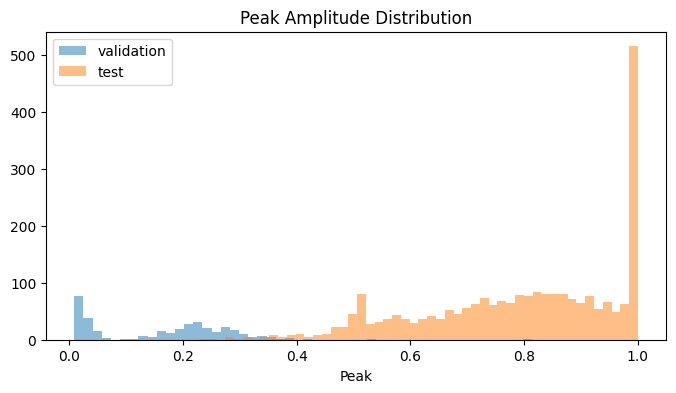

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(
    val_peak,
    bins=50,
    alpha=0.5,
    label="validation"
)

plt.hist(
    test_peak,
    bins=50,
    alpha=0.5,
    label="test"
)

plt.legend()
plt.xlabel("Peak")
plt.title("Peak Amplitude Distribution")
plt.show()